# 09 分级仓位第二版测试与分析

本 Notebook 比较以下三种策略：

1. 原始二元仓位 10/40；
2. 分级仓位 v1；
3. 分级仓位 v2。

v2 保持 30% 部分仓位不变，只收紧部分仓位触发条件：

- 距离均线退出不超过 20 个交易日；
- 收盘价站上快均线；
- 快均线斜率转正；
- 5 日反弹强度达到近期正常波动的 1 倍。

本阶段使用开发股票池，不使用外部验证股票重新优化规则。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_graded_position_v2"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

pd.set_option(
    "display.max_columns",
    150,
)

pd.set_option(
    "display.width",
    220,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}",
)

plt.rcParams[
    "axes.unicode_minus"
] = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("REPORT_DIR:", REPORT_DIR)

from matplotlib import font_manager


def configure_chinese_font() -> str | None:
    """
    从当前系统已安装字体中选择一个支持中文的字体。
    """
    preferred_fonts = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [
                font_name
            ]
            plt.rcParams["axes.unicode_minus"] = False

            print(
                "Matplotlib 中文字体：",
                font_name,
            )

            return font_name

    print(
        "没有发现可用的中文字体，"
        "图中的中文可能无法正常显示"
    )

    return None


chinese_font = configure_chinese_font()

%load_ext autoreload
%autoreload 2

from backtest import (
    run_batch_ma_backtest,
)

from graded_position_strategy import (
    run_batch_graded_ma_backtest,
    summarize_batch_period,
    build_timing_attribution_detail,
    summarize_timing_attribution,
    summarize_position_state_performance,
    build_incremental_daily_detail,
    summarize_incremental_effect,
    plot_stock_nav_comparison,
    compare_period_summaries,
    summarize_pair_comparison
)

PROJECT_ROOT: e:\quant-learning
SRC_DIR: e:\quant-learning\src
REPORT_DIR: e:\quant-learning\reports\ma_graded_position_v2
Matplotlib 中文字体： Microsoft YaHei


In [2]:
DEVELOPMENT_STOCK_LIST = [
    "000001",
    "000002",
    "300750",
    "600036",
    "600519",
]

FAST_WINDOW = 10
SLOW_WINDOW = 40

PARTIAL_POSITION = 0.30

REBOUND_WINDOW = 5
REBOUND_RETURN_THRESHOLD = 0.0

VOLATILITY_WINDOW = 20
FAST_MA_SLOPE_WINDOW = 3
MAX_DAYS_SINCE_EXIT = 20
REBOUND_SCORE_THRESHOLD = 1.0

COMMISSION_RATE = 0.0003
SLIPPAGE_RATE = 0.0002

ANNUAL_RISK_FREE_RATE = 0.0
TRADING_DAYS = 252

DEVELOPMENT_START_DATE = "2018-01-01"
DEVELOPMENT_END_DATE = "2024-12-31"

research_protocol = {
    "stock_count": len(
        DEVELOPMENT_STOCK_LIST
    ),
    "fast_window": FAST_WINDOW,
    "slow_window": SLOW_WINDOW,
    "partial_position": PARTIAL_POSITION,
    "rebound_window": REBOUND_WINDOW,
    "volatility_window": VOLATILITY_WINDOW,
    "fast_ma_slope_window": (
        FAST_MA_SLOPE_WINDOW
    ),
    "max_days_since_exit": (
        MAX_DAYS_SINCE_EXIT
    ),
    "rebound_score_threshold": (
        REBOUND_SCORE_THRESHOLD
    ),
    "start_date": DEVELOPMENT_START_DATE,
    "end_date": DEVELOPMENT_END_DATE,
    "commission_rate": COMMISSION_RATE,
    "slippage_rate": SLIPPAGE_RATE,
}

display(
    pd.DataFrame(
        research_protocol.items(),
        columns=[
            "item",
            "value",
        ],
    )
)

,item,value
0,stock_count,5
1,fast_window,10
2,slow_window,40
3,partial_position,0.3000
4,rebound_window,5
5,volatility_window,20
6,fast_ma_slope_window,3
7,max_days_since_exit,20
8,rebound_score_threshold,1.0000
9,start_date,2018-01-01


In [3]:
binary_summary_all, binary_results = (
    run_batch_ma_backtest(
        stock_list=(
            DEVELOPMENT_STOCK_LIST
        ),
        fast_window=FAST_WINDOW,
        slow_window=SLOW_WINDOW,
        commission_rate=(
            COMMISSION_RATE
        ),
        slippage_rate=(
            SLIPPAGE_RATE
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
        save_result=False,
    )
)

graded_v1_summary_all, graded_v1_results = (
    run_batch_graded_ma_backtest(
        stock_list=(
            DEVELOPMENT_STOCK_LIST
        ),
        fast_window=FAST_WINDOW,
        slow_window=SLOW_WINDOW,
        rebound_window=REBOUND_WINDOW,
        partial_position=PARTIAL_POSITION,
        signal_version="v1",
        rebound_return_threshold=(
            REBOUND_RETURN_THRESHOLD
        ),
        volatility_window=(
            VOLATILITY_WINDOW
        ),
        fast_ma_slope_window=(
            FAST_MA_SLOPE_WINDOW
        ),
        max_days_since_exit=(
            MAX_DAYS_SINCE_EXIT
        ),
        rebound_score_threshold=(
            REBOUND_SCORE_THRESHOLD
        ),
        commission_rate=(
            COMMISSION_RATE
        ),
        slippage_rate=(
            SLIPPAGE_RATE
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
        save_result=False,
    )
)

graded_v2_summary_all, graded_v2_results = (
    run_batch_graded_ma_backtest(
        stock_list=(
            DEVELOPMENT_STOCK_LIST
        ),
        fast_window=FAST_WINDOW,
        slow_window=SLOW_WINDOW,
        rebound_window=REBOUND_WINDOW,
        partial_position=PARTIAL_POSITION,
        signal_version="v2",
        rebound_return_threshold=(
            REBOUND_RETURN_THRESHOLD
        ),
        volatility_window=(
            VOLATILITY_WINDOW
        ),
        fast_ma_slope_window=(
            FAST_MA_SLOPE_WINDOW
        ),
        max_days_since_exit=(
            MAX_DAYS_SINCE_EXIT
        ),
        rebound_score_threshold=(
            REBOUND_SCORE_THRESHOLD
        ),
        commission_rate=(
            COMMISSION_RATE
        ),
        slippage_rate=(
            SLIPPAGE_RATE
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
        save_result=False,
    )
)

正在回测：000001
正在回测：000002
正在回测：300750
正在回测：600036
正在回测：600519
正在回测 v1：000001
正在回测 v1：000002
正在回测 v1：300750
正在回测 v1：600036
正在回测 v1：600519
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519


## 正确性检测


In [4]:
binary_symbols = set(
    binary_results
)

v1_symbols = set(
    graded_v1_results
)

v2_symbols = set(
    graded_v2_results
)

print(
    "binary:",
    sorted(binary_symbols),
)

print(
    "v1:",
    sorted(v1_symbols),
)

print(
    "v2:",
    sorted(v2_symbols),
)

assert binary_symbols == v1_symbols
assert binary_symbols == v2_symbols

print("三组策略股票集合一致")

common_columns = [
    "date",
    "close",
    "asset_return",
    "fast_ma",
    "slow_ma",
    "binary_signal",
    "rebound_return",
    "daily_volatility",
    "rebound_score",
    "fast_ma_slope",
    "days_since_exit",
]

for symbol in sorted(v1_symbols):
    v1_result = (
        graded_v1_results[
            symbol
        ].reset_index(drop=True)
    )

    v2_result = (
        graded_v2_results[
            symbol
        ].reset_index(drop=True)
    )

    assert len(v1_result) == len(v2_result)

    assert v1_result[
        "date"
    ].equals(
        v2_result["date"]
    )

    for column in common_columns:
        if column == "date":
            continue

        left = v1_result[
            column
        ]

        right = v2_result[
            column
        ]

        if pd.api.types.is_bool_dtype(
            left
        ):
            assert left.equals(right), (
                f"{symbol} {column} 不一致"
            )

        else:
            assert np.allclose(
                left,
                right,
                equal_nan=True,
            ), (
                f"{symbol} {column} 不一致"
            )

print("v1 与 v2 公共指标检查通过")

allowed_positions = np.array(
    [
        0.0,
        PARTIAL_POSITION,
        1.0,
    ]
)

for version_name, batch_results in {
    "v1": graded_v1_results,
    "v2": graded_v2_results,
}.items():

    for symbol, result in (
        batch_results.items()
    ):
        valid_position = (
            result["position"]
            .apply(
                lambda value: np.isclose(
                    value,
                    allowed_positions,
                ).any()
            )
        )

        assert valid_position.all(), (
            f"{version_name} "
            f"{symbol} 存在非法仓位"
        )

print("仓位合法性检查通过")

allowed_positions = np.array(
    [
        0.0,
        PARTIAL_POSITION,
        1.0,
    ]
)

for version_name, batch_results in {
    "v1": graded_v1_results,
    "v2": graded_v2_results,
}.items():

    for symbol, result in (
        batch_results.items()
    ):
        valid_position = (
            result["position"]
            .apply(
                lambda value: np.isclose(
                    value,
                    allowed_positions,
                ).any()
            )
        )

        assert valid_position.all(), (
            f"{version_name} "
            f"{symbol} 存在非法仓位"
        )

print("仓位合法性检查通过")

ONE_WAY_COST = (
    COMMISSION_RATE
    + SLIPPAGE_RATE
)

for version_name, batch_results in {
    "v1": graded_v1_results,
    "v2": graded_v2_results,
}.items():

    for symbol, result in (
        batch_results.items()
    ):
        expected_cost = (
            result[
                "position_change"
            ].abs()
            * ONE_WAY_COST
        )

        expected_gross_return = (
            result["position"]
            * result[
                "asset_return"
            ].fillna(0.0)
        )

        expected_net_return = (
            expected_gross_return
            - expected_cost
        )

        assert np.allclose(
            result[
                "transaction_cost"
            ],
            expected_cost,
        )

        assert np.allclose(
            result[
                "gross_strategy_return"
            ],
            expected_gross_return,
        )

        assert np.allclose(
            result[
                "strategy_return"
            ],
            expected_net_return,
        )

print("成本和收益公式检查通过")

ONE_WAY_COST = (
    COMMISSION_RATE
    + SLIPPAGE_RATE
)

for version_name, batch_results in {
    "v1": graded_v1_results,
    "v2": graded_v2_results,
}.items():

    for symbol, result in (
        batch_results.items()
    ):
        expected_cost = (
            result[
                "position_change"
            ].abs()
            * ONE_WAY_COST
        )

        expected_gross_return = (
            result["position"]
            * result[
                "asset_return"
            ].fillna(0.0)
        )

        expected_net_return = (
            expected_gross_return
            - expected_cost
        )

        assert np.allclose(
            result[
                "transaction_cost"
            ],
            expected_cost,
        )

        assert np.allclose(
            result[
                "gross_strategy_return"
            ],
            expected_gross_return,
        )

        assert np.allclose(
            result[
                "strategy_return"
            ],
            expected_net_return,
        )

print("成本和收益公式检查通过")

v2_partial_signal_count = 0

for symbol, result in (
    graded_v2_results.items()
):
    partial_signal_data = (
        result.loc[
            result[
                "partial_rebound_signal"
            ]
        ]
    )

    v2_partial_signal_count += len(
        partial_signal_data
    )

    if partial_signal_data.empty:
        print(
            f"{symbol} 没有触发 v2 部分仓位"
        )
        continue

    assert (
        partial_signal_data[
            "bearish_ma_condition"
        ]
    ).all()

    assert (
        partial_signal_data[
            "recent_exit_condition"
        ]
    ).all()

    assert (
        partial_signal_data[
            "price_above_fast_ma_condition"
        ]
    ).all()

    assert (
        partial_signal_data[
            "fast_ma_turning_up_condition"
        ]
    ).all()

    assert (
        partial_signal_data[
            "strong_rebound_condition"
        ]
    ).all()

    assert partial_signal_data[
        "days_since_exit"
    ].between(
        1,
        MAX_DAYS_SINCE_EXIT,
        inclusive="both",
    ).all()

    assert (
        partial_signal_data[
            "rebound_score"
        ]
        >= REBOUND_SCORE_THRESHOLD
    ).all()

    assert (
        partial_signal_data[
            "fast_ma_slope"
        ] > 0
    ).all()

print(
    "v2 部分仓位信号总数：",
    v2_partial_signal_count,
)

print("v2 触发条件检查通过")

binary: ['000001', '000002', '300750', '600036', '600519']
v1: ['000001', '000002', '300750', '600036', '600519']
v2: ['000001', '000002', '300750', '600036', '600519']
三组策略股票集合一致
v1 与 v2 公共指标检查通过
仓位合法性检查通过
仓位合法性检查通过
成本和收益公式检查通过
成本和收益公式检查通过
v2 部分仓位信号总数： 229
v2 触发条件检查通过


## 正式比较

In [5]:
binary_period_summary = (
    summarize_batch_period(
        batch_results=binary_results,
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name=(
            "binary_10_40"
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )
)

graded_v1_period_summary = (
    summarize_batch_period(
        batch_results=(
            graded_v1_results
        ),
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name="graded_v1",
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )
)

graded_v2_period_summary = (
    summarize_batch_period(
        batch_results=(
            graded_v2_results
        ),
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name="graded_v2",
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )
)

period_check = pd.concat(
    [
        binary_period_summary[
            [
                "symbol",
                "strategy_name",
                "start_date",
                "end_date",
                "trade_days",
            ]
        ],
        graded_v1_period_summary[
            [
                "symbol",
                "strategy_name",
                "start_date",
                "end_date",
                "trade_days",
            ]
        ],
        graded_v2_period_summary[
            [
                "symbol",
                "strategy_name",
                "start_date",
                "end_date",
                "trade_days",
            ]
        ],
    ],
    ignore_index=True,
)

display(
    period_check.sort_values(
        [
            "symbol",
            "strategy_name",
        ]
    )
)

,symbol,strategy_name,start_date,end_date,trade_days
3,000001,binary_10_40,2018-01-02,2024-12-31,1699
8,000001,graded_v1,2018-01-02,2024-12-31,1699
13,000001,graded_v2,2018-01-02,2024-12-31,1699
4,000002,binary_10_40,2018-01-02,2024-12-31,1699
9,000002,graded_v1,2018-01-02,2024-12-31,1699
14,000002,graded_v2,2018-01-02,2024-12-31,1699
0,300750,binary_10_40,2018-08-07,2024-12-31,1554
5,300750,graded_v1,2018-08-07,2024-12-31,1554
10,300750,graded_v2,2018-08-07,2024-12-31,1554
2,600036,binary_10_40,2018-01-02,2024-12-31,1699


In [6]:
performance_columns = [
    "symbol",
    "strategy_name",
    "strategy_annual_return",
    "strategy_sharpe",
    "strategy_max_drawdown",
    "strategy_calmar",
    "excess_annual_return",
    "exposure",
    "total_trade_count",
    "total_transaction_cost",
    "total_turnover",
    "full_position_rate",
    "partial_position_rate",
    "cash_rate",
]

performance_detail = pd.concat(
    [
        binary_period_summary[
            performance_columns
        ],
        graded_v1_period_summary[
            performance_columns
        ],
        graded_v2_period_summary[
            performance_columns
        ],
    ],
    ignore_index=True,
)

display(
    performance_detail.sort_values(
        [
            "symbol",
            "strategy_name",
        ]
    )
)

,symbol,strategy_name,strategy_annual_return,strategy_sharpe,strategy_max_drawdown,strategy_calmar,excess_annual_return,exposure,total_trade_count,total_transaction_cost,total_turnover,full_position_rate,partial_position_rate,cash_rate
3,000001,binary_10_40,-0.0416,-0.0657,-0.5162,-0.0806,-0.0499,0.4715,50,0.0250,50.0000,0.4715,0.0000,0.5285
8,000001,graded_v1,-0.0401,-0.0544,-0.5182,-0.0773,-0.0483,0.5235,198,0.0436,87.2000,0.4715,0.1736,0.3549
13,000001,graded_v2,-0.0308,-0.0171,-0.4899,-0.0629,-0.0391,0.4762,71,0.0274,54.8000,0.4715,0.0159,0.5127
4,000002,binary_10_40,-0.1880,-0.7106,-0.8436,-0.2229,-0.0283,0.3985,58,0.0290,58.0000,0.3985,0.0000,0.6015
9,000002,graded_v1,-0.1885,-0.6944,-0.8475,-0.2224,-0.0287,0.4590,237,0.0525,105.1000,0.3985,0.2019,0.3996
14,000002,graded_v2,-0.1880,-0.7089,-0.8435,-0.2228,-0.0282,0.4038,87,0.0329,65.8000,0.3985,0.0177,0.5839
0,300750,binary_10_40,0.3979,1.0879,-0.3350,1.1877,0.0229,0.5611,41,0.0205,41.0000,0.5611,0.0000,0.4389
5,300750,graded_v1,0.3856,1.0585,-0.3547,1.0872,0.0105,0.6094,151,0.0340,68.0000,0.5611,0.1609,0.2780
10,300750,graded_v2,0.3903,1.0730,-0.3369,1.1587,0.0153,0.5652,56,0.0223,44.6000,0.5611,0.0135,0.4254
2,600036,binary_10_40,-0.0259,-0.0241,-0.3622,-0.0716,-0.1146,0.5185,58,0.0290,58.0000,0.5185,0.0000,0.4815


In [7]:
performance_summary = (
    performance_detail.groupby(
        "strategy_name",
        as_index=False,
    )
    .agg(
        stock_count=(
            "symbol",
            "nunique",
        ),
        avg_annual_return=(
            "strategy_annual_return",
            "mean",
        ),
        median_annual_return=(
            "strategy_annual_return",
            "median",
        ),
        avg_sharpe=(
            "strategy_sharpe",
            "mean",
        ),
        median_sharpe=(
            "strategy_sharpe",
            "median",
        ),
        avg_max_drawdown=(
            "strategy_max_drawdown",
            "mean",
        ),
        avg_calmar=(
            "strategy_calmar",
            "mean",
        ),
        avg_excess_return=(
            "excess_annual_return",
            "mean",
        ),
        avg_exposure=(
            "exposure",
            "mean",
        ),
        avg_trade_count=(
            "total_trade_count",
            "mean",
        ),
        avg_turnover=(
            "total_turnover",
            "mean",
        ),
        avg_transaction_cost=(
            "total_transaction_cost",
            "mean",
        ),
        avg_partial_position_rate=(
            "partial_position_rate",
            "mean",
        ),
    )
)

display(performance_summary)

,strategy_name,stock_count,avg_annual_return,median_annual_return,avg_sharpe,median_sharpe,avg_max_drawdown,avg_calmar,avg_excess_return,avg_exposure,avg_trade_count,avg_turnover,avg_transaction_cost,avg_partial_position_rate
0,binary_10_40,5,0.0360,-0.0259,0.1137,-0.0241,-0.4961,0.1803,-0.0556,0.4945,51.0000,51.0000,0.0255,0.0000
1,graded_v1,5,0.0366,-0.0186,0.1271,0.0151,-0.5018,0.1688,-0.0550,0.5494,198.8000,88.5000,0.0442,0.1831
2,graded_v2,5,0.0380,-0.0170,0.1275,0.0206,-0.4849,0.1803,-0.0536,0.4996,76.4000,57.4800,0.0287,0.0171


In [8]:
binary_vs_v1 = (
    compare_period_summaries(
        baseline_summary=(
            binary_period_summary
        ),
        candidate_summary=(
            graded_v1_period_summary
        ),
        baseline_name="binary",
        candidate_name="v1",
    )
)

binary_vs_v2 = (
    compare_period_summaries(
        baseline_summary=(
            binary_period_summary
        ),
        candidate_summary=(
            graded_v2_period_summary
        ),
        baseline_name="binary",
        candidate_name="v2",
    )
)

v1_vs_v2 = (
    compare_period_summaries(
        baseline_summary=(
            graded_v1_period_summary
        ),
        candidate_summary=(
            graded_v2_period_summary
        ),
        baseline_name="v1",
        candidate_name="v2",
    )
)

In [9]:
pair_summary = pd.concat(
    [
        summarize_pair_comparison(
            binary_vs_v1
        ),
        summarize_pair_comparison(
            binary_vs_v2
        ),
        summarize_pair_comparison(
            v1_vs_v2
        ),
    ],
    ignore_index=True,
)

display(pair_summary)

,baseline_name,candidate_name,stock_count,avg_annual_return_diff,median_annual_return_diff,annual_return_win_rate,avg_sharpe_diff,median_sharpe_diff,sharpe_win_rate,avg_drawdown_diff,drawdown_win_rate,avg_calmar_diff,calmar_win_rate,avg_excess_return_diff,excess_return_win_rate,avg_exposure_diff,avg_trade_count_diff,avg_turnover_diff,avg_transaction_cost_diff
0,binary,v1,5,0.0006,0.0015,0.6000,0.0135,0.0162,0.8000,-0.0057,0.2000,-0.0115,0.8000,0.0006,0.6000,0.0549,147.8000,37.5000,0.0187
1,binary,v2,5,0.0020,0.0000,0.6000,0.0138,0.0017,0.6000,0.0111,0.6000,0.0000,0.6000,0.0020,0.6000,0.0051,25.4000,6.4800,0.0032
2,v1,v2,5,0.0014,0.0016,0.8000,0.0004,0.0055,0.6000,0.0168,0.8000,0.0116,0.4000,0.0014,0.8000,-0.0498,-122.4000,-31.0200,-0.0155


In [10]:
v1_v2_columns = [
    "symbol",
    "strategy_annual_return_diff",
    "strategy_sharpe_diff",
    "strategy_max_drawdown_diff",
    "strategy_calmar_diff",
    "excess_annual_return_diff",
    "exposure_diff",
    "total_trade_count_diff",
    "total_turnover_diff",
    "total_transaction_cost_diff",
    "partial_position_rate_diff",
]

display(
    v1_vs_v2[
        v1_v2_columns
    ].sort_values(
        "strategy_sharpe_diff",
        ascending=False,
    )
)

,symbol,strategy_annual_return_diff,strategy_sharpe_diff,strategy_max_drawdown_diff,strategy_calmar_diff,excess_annual_return_diff,exposure_diff,total_trade_count_diff,total_turnover_diff,total_transaction_cost_diff,partial_position_rate_diff
3,000001,0.0093,0.0374,0.0283,0.0144,0.0093,-0.0473,-127,-32.4000,-0.0162,-0.1577
0,300750,0.0048,0.0144,0.0178,0.0714,0.0048,-0.0442,-95,-23.4000,-0.0117,-0.1474
2,600036,0.0016,0.0055,0.0483,-0.0025,0.0016,-0.0521,-123,-30.6000,-0.0153,-0.1736
4,000002,0.0005,-0.0146,0.0040,-0.0005,0.0005,-0.0553,-150,-39.3000,-0.0196,-0.1842
1,600519,-0.0093,-0.0409,-0.0141,-0.0251,-0.0093,-0.0501,-117,-29.4000,-0.0147,-0.1672


## 市场状态与策略归因

In [12]:
binary_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=binary_results,
        strategy_name="binary_10_40",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

v1_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=(
            graded_v1_results
        ),
        strategy_name="graded_v1",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

v2_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=(
            graded_v2_results
        ),
        strategy_name="graded_v2",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

all_attribution_detail = pd.concat(
    [
        binary_attribution_detail,
        v1_attribution_detail,
        v2_attribution_detail,
    ],
    ignore_index=True,
)

attribution_summary = (
    summarize_timing_attribution(
        attribution_detail=(
            all_attribution_detail
        ),
        group_columns=[
            "strategy_name",
        ],
    )
)

display(
    attribution_summary[
        [
            "strategy_name",
            "active_return_sum",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "net_timing_benefit",
            "benefit_cost_ratio",
        ]
    ]
)

,strategy_name,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,net_timing_benefit,benefit_cost_ratio
0,binary_10_40,-2.8560,-1.8892,33.9557,31.2272,0.1275,-2.7285,0.9162
1,graded_v1,-2.7774,-1.8412,30.3885,27.8324,0.2213,-2.5561,0.9093
2,graded_v2,-2.7645,-1.8008,33.5897,30.9689,0.1437,-2.6208,0.9180


In [14]:
attribution_indexed = (
    attribution_summary
    .set_index("strategy_name")
)

binary_attribution = (
    attribution_indexed.loc[
        "binary_10_40"
    ]
)

v1_attribution = (
    attribution_indexed.loc[
        "graded_v1"
    ]
)

v2_attribution = (
    attribution_indexed.loc[
        "graded_v2"
    ]
)

attribution_comparison = pd.DataFrame(
    {
        "metric": [
            "错过上涨减少量",
            "规避下跌收益减少量",
            "规避下跌收益保留率",
            "benefit_cost_ratio",
            "主动对数收益",
        ],
        "v1": [
            (
                binary_attribution[
                    "missed_upside_loss"
                ]
                - v1_attribution[
                    "missed_upside_loss"
                ]
            ),
            (
                binary_attribution[
                    "avoided_downside_benefit"
                ]
                - v1_attribution[
                    "avoided_downside_benefit"
                ]
            ),
            (
                v1_attribution[
                    "avoided_downside_benefit"
                ]
                / binary_attribution[
                    "avoided_downside_benefit"
                ]
            ),
            v1_attribution[
                "benefit_cost_ratio"
            ],
            v1_attribution[
                "active_log_return_sum"
            ],
        ],
        "v2": [
            (
                binary_attribution[
                    "missed_upside_loss"
                ]
                - v2_attribution[
                    "missed_upside_loss"
                ]
            ),
            (
                binary_attribution[
                    "avoided_downside_benefit"
                ]
                - v2_attribution[
                    "avoided_downside_benefit"
                ]
            ),
            (
                v2_attribution[
                    "avoided_downside_benefit"
                ]
                / binary_attribution[
                    "avoided_downside_benefit"
                ]
            ),
            v2_attribution[
                "benefit_cost_ratio"
            ],
            v2_attribution[
                "active_log_return_sum"
            ],
        ],
    }
)

display(attribution_comparison)

,metric,v1,v2
0,错过上涨减少量,3.5672,0.3659
1,规避下跌收益减少量,3.3948,0.2582
2,规避下跌收益保留率,0.8913,0.9917
3,benefit_cost_ratio,0.9093,0.9180
4,主动对数收益,-1.8412,-1.8008


In [15]:
position_state_detail = pd.concat(
    [
        v1_attribution_detail,
        v2_attribution_detail,
    ],
    ignore_index=True,
)

position_state_summary = (
    summarize_position_state_performance(
        attribution_detail=(
            position_state_detail
        ),
        group_columns=[
            "strategy_name",
            "position_state",
        ],
    )
)

display(
    position_state_summary[
        [
            "strategy_name",
            "position_state",
            "observation_count",
            "observation_rate",
            "average_position",
            "strategy_mean_daily_return",
            "benchmark_mean_daily_return",
            "active_mean_daily_return",
            "active_log_return_sum",
            "missed_upside_sum",
            "avoided_downside_sum",
            "transaction_cost_sum",
        ]
    ]
)

,strategy_name,position_state,observation_count,observation_rate,average_position,strategy_mean_daily_return,benchmark_mean_daily_return,active_mean_daily_return,active_log_return_sum,missed_upside_sum,avoided_downside_sum,transaction_cost_sum
0,graded_v1,cash,2699,0.3232,0.0000,-0.0000,0.0008,-0.0008,-1.6328,-22.0651,19.9113,0.1080
1,graded_v1,full,4119,0.4933,1.0000,0.0004,0.0004,-0.0000,-0.0479,0.0000,0.0000,0.0479
2,graded_v1,partial,1532,0.1835,0.3000,0.0001,0.0004,-0.0003,-0.1605,-8.3234,7.9211,0.0653
3,graded_v2,cash,4088,0.4896,0.0000,-0.0000,0.0006,-0.0006,-1.5081,-32.7359,30.3664,0.0716
4,graded_v2,full,4119,0.4933,1.0000,0.0004,0.0004,-0.0000,-0.0611,0.0000,0.0000,0.0612
5,graded_v2,partial,143,0.0171,0.3000,0.0007,0.0025,-0.0018,-0.2316,-0.8538,0.6025,0.0109


In [16]:
trigger_comparison = pd.DataFrame(
    {
        "version": [
            "v1",
            "v2",
        ],
        "avg_partial_position_rate": [
            graded_v1_period_summary[
                "partial_position_rate"
            ].mean(),
            graded_v2_period_summary[
                "partial_position_rate"
            ].mean(),
        ],
        "avg_exposure": [
            graded_v1_period_summary[
                "exposure"
            ].mean(),
            graded_v2_period_summary[
                "exposure"
            ].mean(),
        ],
        "avg_trade_count": [
            graded_v1_period_summary[
                "total_trade_count"
            ].mean(),
            graded_v2_period_summary[
                "total_trade_count"
            ].mean(),
        ],
        "avg_turnover": [
            graded_v1_period_summary[
                "total_turnover"
            ].mean(),
            graded_v2_period_summary[
                "total_turnover"
            ].mean(),
        ],
        "avg_transaction_cost": [
            graded_v1_period_summary[
                "total_transaction_cost"
            ].mean(),
            graded_v2_period_summary[
                "total_transaction_cost"
            ].mean(),
        ],
    }
)

display(trigger_comparison)

,version,avg_partial_position_rate,avg_exposure,avg_trade_count,avg_turnover,avg_transaction_cost
0,v1,0.1831,0.5494,198.8000,88.5000,0.0442
1,v2,0.0171,0.4996,76.4000,57.4800,0.0287


In [17]:
funnel_rows = []

for symbol, result in (
    graded_v2_results.items()
):
    data = result.copy()

    data["date"] = pd.to_datetime(
        data["date"]
    )

    evaluation_mask = (
        data["slow_ma"]
        .shift(1)
        .notna()
    )

    evaluation_mask &= (
        data["date"]
        >= pd.Timestamp(
            DEVELOPMENT_START_DATE
        )
    )

    evaluation_mask &= (
        data["date"]
        <= pd.Timestamp(
            DEVELOPMENT_END_DATE
        )
    )

    data = data.loc[
        evaluation_mask
    ].copy()

    bearish = (
        data[
            "bearish_ma_condition"
        ]
    )

    recent_exit = (
        bearish
        & data[
            "recent_exit_condition"
        ]
    )

    price_above = (
        recent_exit
        & data[
            "price_above_fast_ma_condition"
        ]
    )

    slope_up = (
        price_above
        & data[
            "fast_ma_turning_up_condition"
        ]
    )

    strong_rebound = (
        slope_up
        & data[
            "strong_rebound_condition"
        ]
    )

    funnel_rows.extend(
        [
            {
                "symbol": symbol,
                "stage": "1_bearish_ma",
                "count": int(
                    bearish.sum()
                ),
            },
            {
                "symbol": symbol,
                "stage": "2_recent_exit",
                "count": int(
                    recent_exit.sum()
                ),
            },
            {
                "symbol": symbol,
                "stage": "3_price_above_fast_ma",
                "count": int(
                    price_above.sum()
                ),
            },
            {
                "symbol": symbol,
                "stage": "4_fast_ma_slope_up",
                "count": int(
                    slope_up.sum()
                ),
            },
            {
                "symbol": symbol,
                "stage": "5_strong_rebound",
                "count": int(
                    strong_rebound.sum()
                ),
            },
        ]
    )

filter_funnel_detail = pd.DataFrame(
    funnel_rows
)

filter_funnel_summary = (
    filter_funnel_detail.groupby(
        "stage",
        as_index=False,
    )
    .agg(
        total_count=(
            "count",
            "sum",
        ),
        avg_count_per_stock=(
            "count",
            "mean",
        ),
    )
)

filter_funnel_summary[
    "retention_rate_vs_previous"
] = (
    filter_funnel_summary[
        "total_count"
    ]
    / filter_funnel_summary[
        "total_count"
    ].shift(1)
)

display(filter_funnel_summary)

,stage,total_count,avg_count_per_stock,retention_rate_vs_previous
0,1_bearish_ma,4232,846.4000,NaN
1,2_recent_exit,1994,398.8000,0.4712
2,3_price_above_fast_ma,796,159.2000,0.3992
3,4_fast_ma_slope_up,375,75.0000,0.4711
4,5_strong_rebound,143,28.6000,0.3813


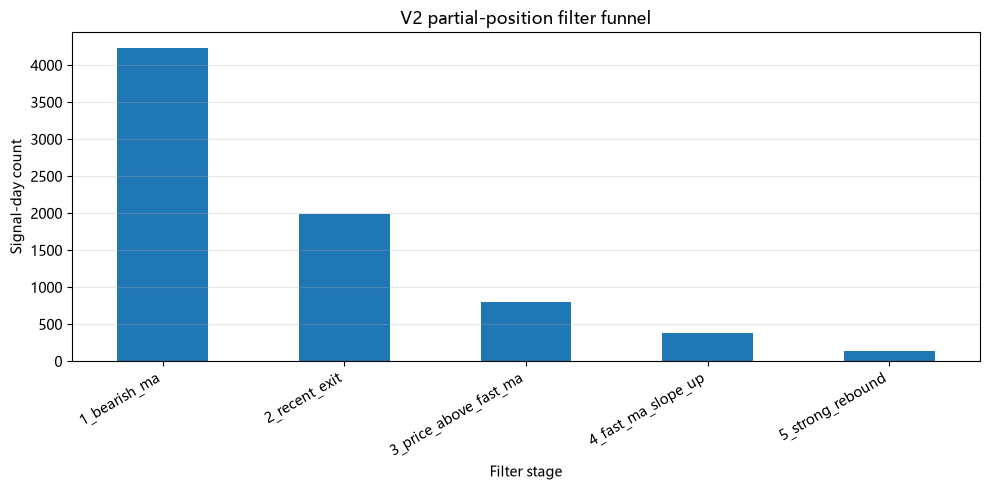

In [18]:
ax = (
    filter_funnel_summary
    .set_index("stage")
    [
        "total_count"
    ]
    .plot(
        kind="bar",
        figsize=(10, 5),
    )
)

ax.set_xlabel("Filter stage")
ax.set_ylabel("Signal-day count")
ax.set_title(
    "V2 partial-position filter funnel"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

## 精确比较

In [19]:
incremental_detail_v1 = (
    build_incremental_daily_detail(
        binary_results=binary_results,
        graded_results=(
            graded_v1_results
        ),
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

incremental_summary_v1 = (
    summarize_incremental_effect(
        incremental_detail=(
            incremental_detail_v1
        ),
        group_columns=[
            "incremental_state",
        ],
    )
)

incremental_summary_v1[
    "version"
] = "v1"


incremental_detail_v2 = (
    build_incremental_daily_detail(
        binary_results=binary_results,
        graded_results=(
            graded_v2_results
        ),
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

incremental_summary_v2 = (
    summarize_incremental_effect(
        incremental_detail=(
            incremental_detail_v2
        ),
        group_columns=[
            "incremental_state",
        ],
    )
)

incremental_summary_v2[
    "version"
] = "v2"


incremental_state_summary = (
    pd.concat(
        [
            incremental_summary_v1,
            incremental_summary_v2,
        ],
        ignore_index=True,
    )
)

display(
    incremental_state_summary[
        [
            "version",
            "incremental_state",
            "observation_count",
            "average_position_increment",
            "average_asset_return",
            "incremental_gross_return_sum",
            "incremental_transaction_cost_sum",
            "incremental_net_return_sum",
            "incremental_log_return_sum",
            "positive_incremental_day_rate",
        ]
    ]
)

,version,incremental_state,observation_count,average_position_increment,average_asset_return,incremental_gross_return_sum,incremental_transaction_cost_sum,incremental_net_return_sum,incremental_log_return_sum,positive_incremental_day_rate
0,v1,added_exposure_up,699,0.3000,0.0170,3.5672,0.0295,3.5376,3.5192,0.9971
1,v1,added_exposure_flat,35,0.3000,0.0000,0.0000,0.0018,-0.0018,-0.0018,0.0000
2,v1,same_exposure,6818,0.0000,0.0006,0.0000,0.0319,-0.0319,-0.0320,0.0157
3,v1,added_exposure_down,798,0.3000,-0.0142,-3.3948,0.0304,-3.4252,-3.4374,0.0000
4,v2,added_exposure_up,69,0.3000,0.0177,0.3659,0.0046,0.3613,0.3591,1.0000
5,v2,added_exposure_flat,4,0.3000,0.0000,0.0000,0.0006,-0.0006,-0.0006,0.0000
6,v2,same_exposure,8207,0.0000,0.0005,0.0000,0.0052,-0.0052,-0.0053,0.0023
7,v2,added_exposure_down,70,0.3000,-0.0123,-0.2582,0.0057,-0.2639,-0.2648,0.0000


In [20]:
display(
    incremental_state_summary.loc[
        incremental_state_summary[
            "incremental_state"
        ].isin(
            [
                "added_exposure_up",
                "added_exposure_down",
                "added_exposure_flat",
            ]
        )
    ]
)

,incremental_state,observation_count,stock_count,average_position_increment,average_asset_return,incremental_gross_return_sum,incremental_transaction_cost_sum,incremental_net_return_sum,incremental_log_return_sum,positive_incremental_day_rate,version
0,added_exposure_up,699,5,0.3000,0.0170,3.5672,0.0295,3.5376,3.5192,0.9971,v1
1,added_exposure_flat,35,5,0.3000,0.0000,0.0000,0.0018,-0.0018,-0.0018,0.0000,v1
3,added_exposure_down,798,5,0.3000,-0.0142,-3.3948,0.0304,-3.4252,-3.4374,0.0000,v1
4,added_exposure_up,69,5,0.3000,0.0177,0.3659,0.0046,0.3613,0.3591,1.0000,v2
5,added_exposure_flat,4,3,0.3000,0.0000,0.0000,0.0006,-0.0006,-0.0006,0.0000,v2
7,added_exposure_down,70,5,0.3000,-0.0123,-0.2582,0.0057,-0.2639,-0.2648,0.0000,v2


In [21]:
stock_incremental_v1 = (
    summarize_incremental_effect(
        incremental_detail=(
            incremental_detail_v1
        ),
        group_columns=[
            "symbol",
        ],
    )
)

stock_incremental_v1[
    "version"
] = "v1"

stock_incremental_v2 = (
    summarize_incremental_effect(
        incremental_detail=(
            incremental_detail_v2
        ),
        group_columns=[
            "symbol",
        ],
    )
)

stock_incremental_v2[
    "version"
] = "v2"

stock_incremental_summary = (
    pd.concat(
        [
            stock_incremental_v1,
            stock_incremental_v2,
        ],
        ignore_index=True,
    )
)

display(
    stock_incremental_summary[
        [
            "version",
            "symbol",
            "observation_count",
            "incremental_net_return_sum",
            "incremental_log_return_sum",
            "positive_incremental_day_rate",
        ]
    ].sort_values(
        [
            "version",
            "incremental_log_return_sum",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

,version,symbol,observation_count,incremental_net_return_sum,incremental_log_return_sum,positive_incremental_day_rate
0,v1,600036,1699,0.0550,0.0502,0.1089
1,v1,600519,1699,0.0507,0.0451,0.0930
2,v1,000001,1699,0.0165,0.0109,0.0912
3,v1,000002,1699,0.0045,-0.0037,0.1012
4,v1,300750,1554,-0.0480,-0.0546,0.0862
5,v2,000001,1699,0.0766,0.0756,0.0129
6,v2,600036,1699,0.0624,0.0614,0.0165
7,v2,000002,1699,0.0010,0.0004,0.0094
8,v2,600519,1699,-0.0152,-0.0154,0.0071
9,v2,300750,1554,-0.0332,-0.0335,0.0064


In [22]:
stock_incremental_win_rate = (
    stock_incremental_summary.groupby(
        "version",
        as_index=False,
    )
    .agg(
        stock_count=(
            "symbol",
            "nunique",
        ),
        incremental_stock_win_rate=(
            "incremental_log_return_sum",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
        avg_incremental_log_return=(
            "incremental_log_return_sum",
            "mean",
        ),
        median_incremental_log_return=(
            "incremental_log_return_sum",
            "median",
        ),
        worst_incremental_log_return=(
            "incremental_log_return_sum",
            "min",
        ),
    )
)

display(stock_incremental_win_rate)

,version,stock_count,incremental_stock_win_rate,avg_incremental_log_return,median_incremental_log_return,worst_incremental_log_return
0,v1,5,0.6000,0.0096,0.0109,-0.0546
1,v2,5,0.6000,0.0177,0.0004,-0.0335


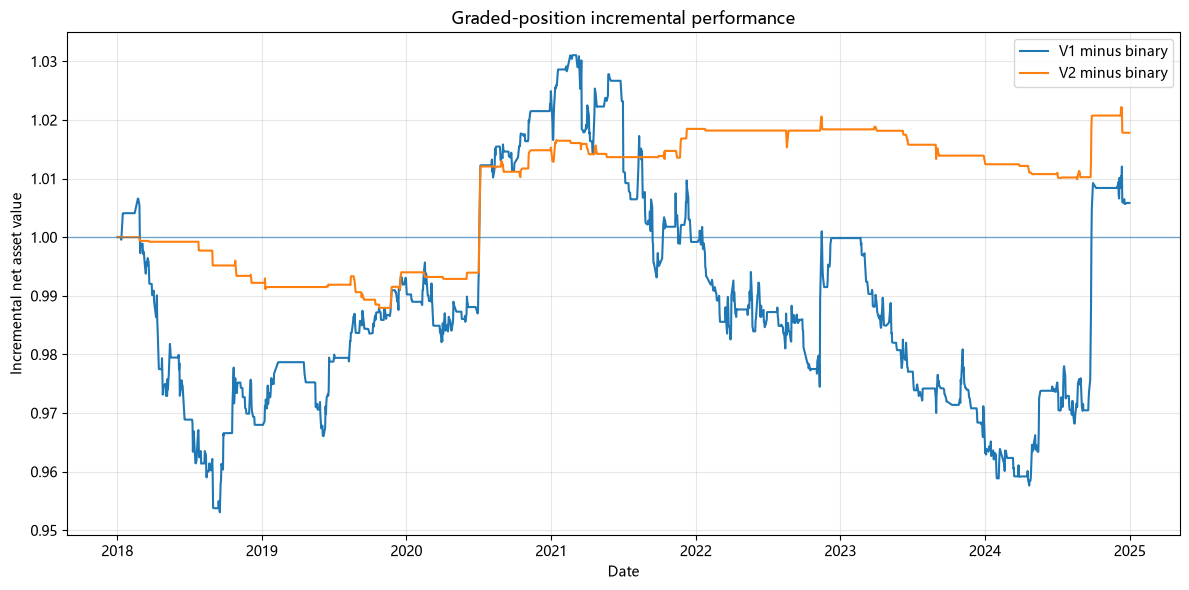

In [23]:
def build_incremental_portfolio_nav(
    incremental_detail: pd.DataFrame,
    version: str,
) -> pd.DataFrame:
    daily = (
        incremental_detail.groupby(
            "date",
            as_index=False,
        )
        .agg(
            incremental_return=(
                "incremental_net_return",
                "mean",
            )
        )
        .sort_values("date")
    )

    daily["incremental_nav"] = (
        1.0
        + daily[
            "incremental_return"
        ]
    ).cumprod()

    daily["version"] = version

    return daily

incremental_nav_v1 = (
    build_incremental_portfolio_nav(
        incremental_detail_v1,
        "v1",
    )
)

incremental_nav_v2 = (
    build_incremental_portfolio_nav(
        incremental_detail_v2,
        "v2",
    )
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    incremental_nav_v1["date"],
    incremental_nav_v1[
        "incremental_nav"
    ],
    label="V1 minus binary",
)

ax.plot(
    incremental_nav_v2["date"],
    incremental_nav_v2[
        "incremental_nav"
    ],
    label="V2 minus binary",
)

ax.axhline(
    1.0,
    linewidth=1.0,
    alpha=0.6,
)

ax.set_xlabel("Date")
ax.set_ylabel(
    "Incremental net asset value"
)

ax.set_title(
    "Graded-position incremental performance"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()
plt.show()

In [25]:
def build_annual_strategy_returns(
    batch_results: dict[
        str,
        pd.DataFrame,
    ],
    strategy_name: str,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    rows = []

    for symbol, result in (
        batch_results.items()
    ):
        data = result.copy()

        data["date"] = pd.to_datetime(
            data["date"]
        )

        evaluation_mask = (
            data["slow_ma"]
            .shift(1)
            .notna()
        )

        evaluation_mask &= (
            data["date"]
            >= pd.Timestamp(start_date)
        )

        evaluation_mask &= (
            data["date"]
            <= pd.Timestamp(end_date)
        )

        data = data.loc[
            evaluation_mask
        ].copy()

        data["year"] = (
            data["date"].dt.year
        )

        for year, year_data in (
            data.groupby("year")
        ):
            strategy_return = (
                (
                    1.0
                    + year_data[
                        "strategy_return"
                    ]
                ).prod()
                - 1.0
            )

            benchmark_return = (
                (
                    1.0
                    + year_data[
                        "asset_return"
                    ].fillna(0.0)
                ).prod()
                - 1.0
            )

            rows.append(
                {
                    "strategy_name": (
                        strategy_name
                    ),
                    "symbol": symbol,
                    "year": int(year),
                    "strategy_return": (
                        strategy_return
                    ),
                    "benchmark_return": (
                        benchmark_return
                    ),
                    "excess_return": (
                        strategy_return
                        - benchmark_return
                    ),
                }
            )

    return pd.DataFrame(rows)

annual_detail = pd.concat(
    [
        build_annual_strategy_returns(
            binary_results,
            "binary_10_40",
            DEVELOPMENT_START_DATE,
            DEVELOPMENT_END_DATE,
        ),
        build_annual_strategy_returns(
            graded_v1_results,
            "graded_v1",
            DEVELOPMENT_START_DATE,
            DEVELOPMENT_END_DATE,
        ),
        build_annual_strategy_returns(
            graded_v2_results,
            "graded_v2",
            DEVELOPMENT_START_DATE,
            DEVELOPMENT_END_DATE,
        ),
    ],
    ignore_index=True,
)

annual_summary = (
    annual_detail.groupby(
        [
            "strategy_name",
            "year",
        ],
        as_index=False,
    )
    .agg(
        stock_count=(
            "symbol",
            "nunique",
        ),
        avg_strategy_return=(
            "strategy_return",
            "mean",
        ),
        median_strategy_return=(
            "strategy_return",
            "median",
        ),
        avg_excess_return=(
            "excess_return",
            "mean",
        ),
        excess_win_rate=(
            "excess_return",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
    )
)
annual_return_matrix = (
    annual_summary.pivot(
        index="year",
        columns="strategy_name",
        values="avg_strategy_return",
    )
)

display(annual_return_matrix)

strategy_name,binary_10_40,graded_v1,graded_v2
year,,,
2018,-0.1091,-0.1291,-0.1156
2019,0.3290,0.3611,0.3316
2020,0.2736,0.2945,0.2890
2021,0.0179,-0.0158,0.0215
2022,-0.0955,-0.0966,-0.0957
2023,-0.0555,-0.0823,-0.0596
2024,0.0634,0.1001,0.0679


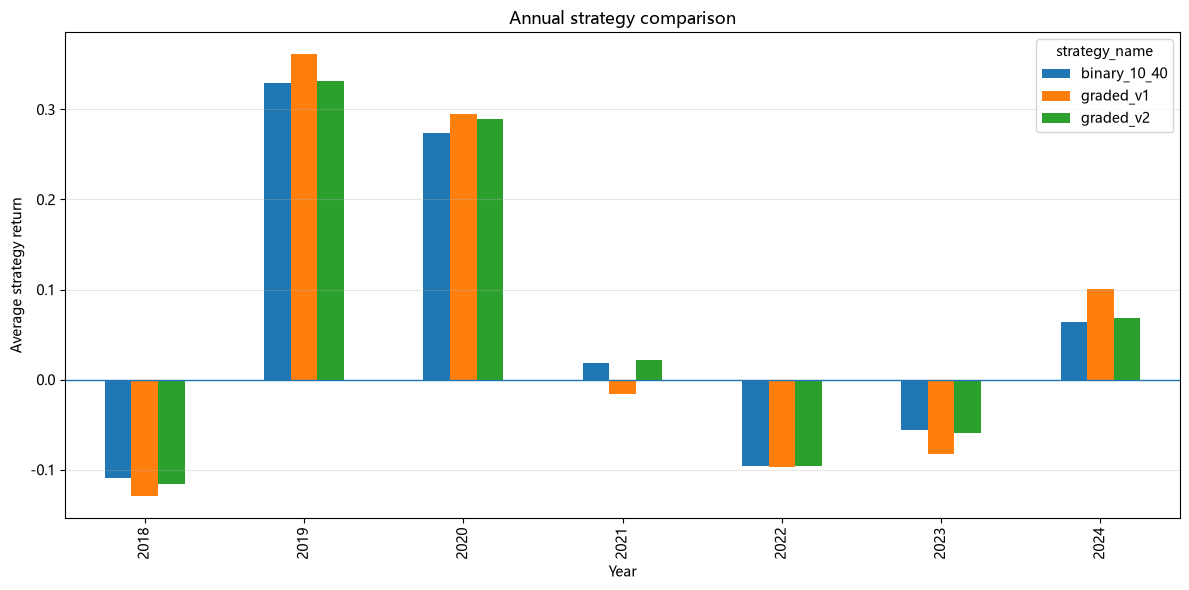

In [26]:
ax = annual_return_matrix.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Average strategy return"
)

ax.set_title(
    "Annual strategy comparison"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

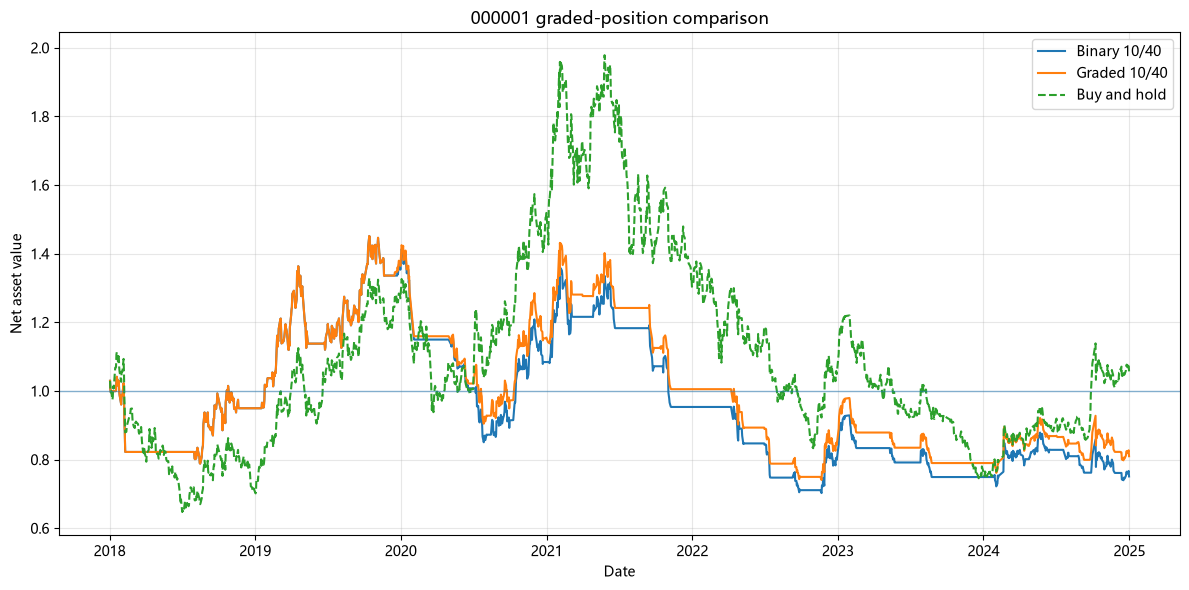

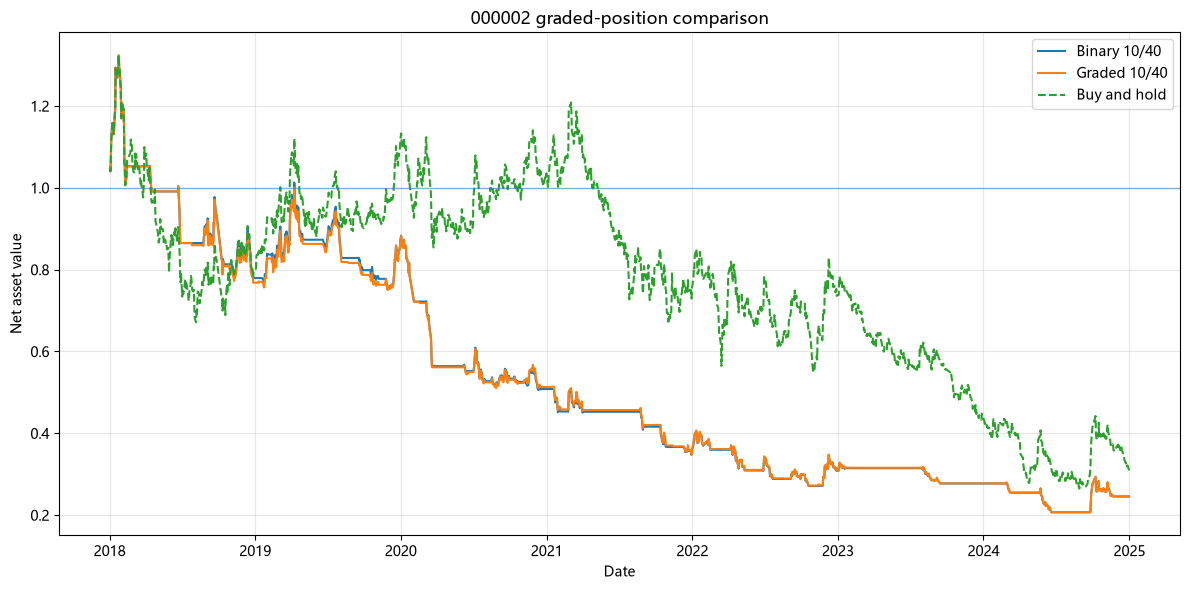

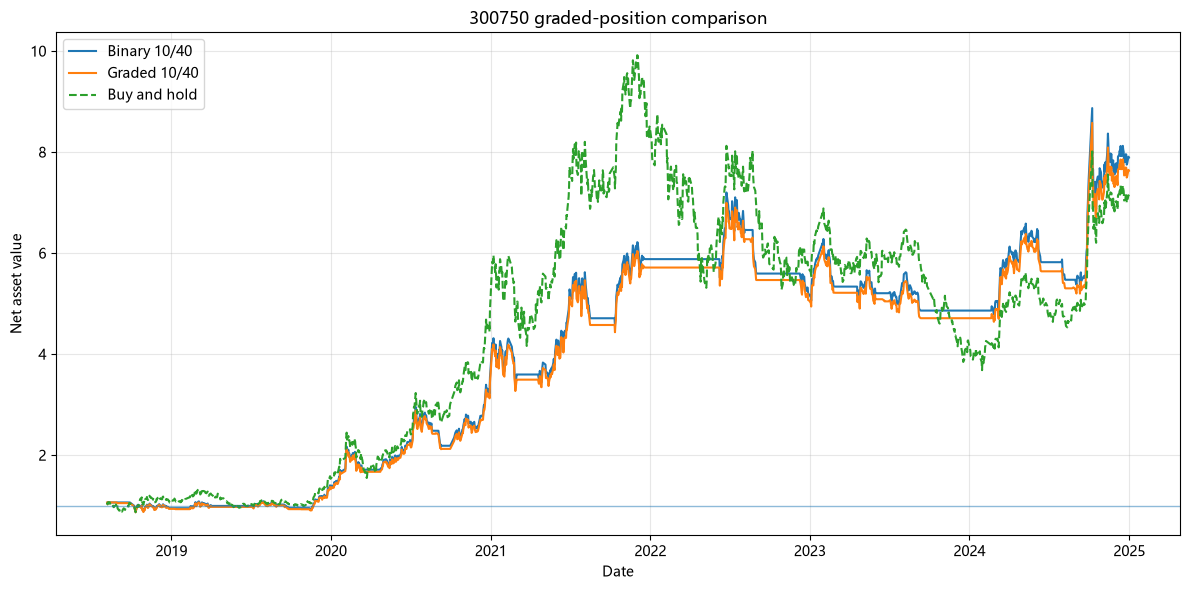

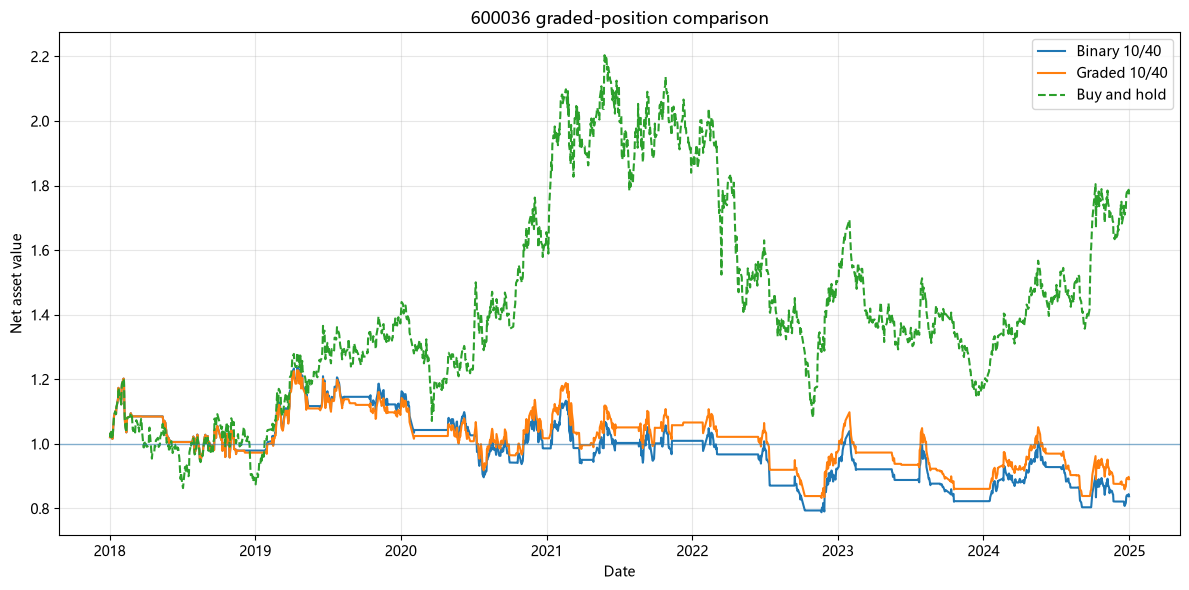

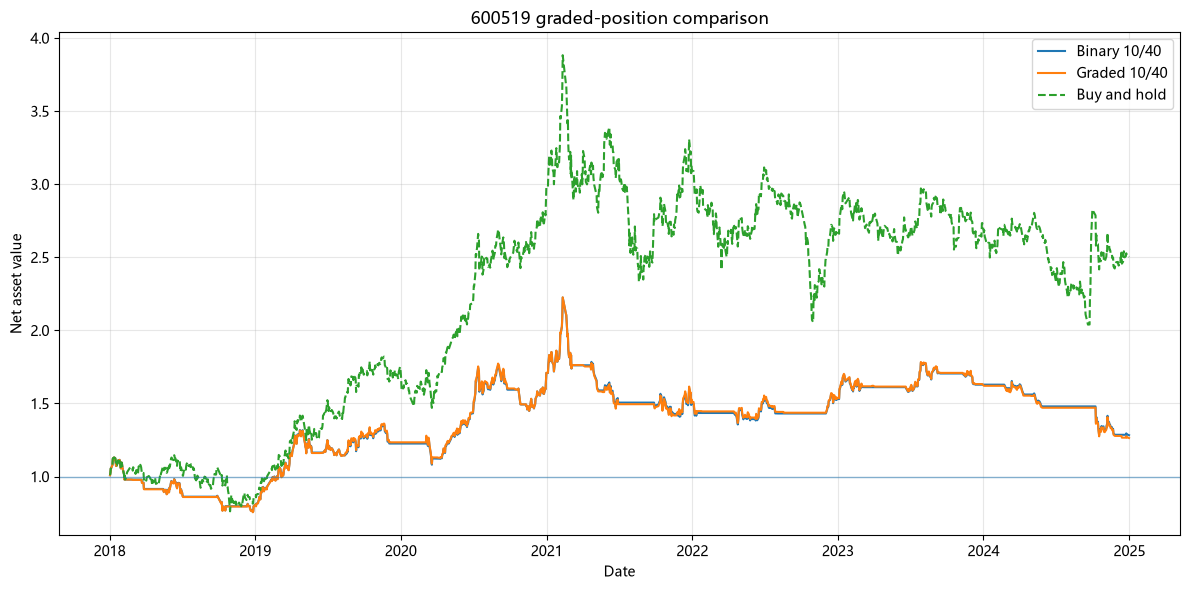

In [28]:
for symbol in sorted(
    binary_symbols
):
    fig, ax = (
        plot_stock_nav_comparison(
            binary_result=(
                binary_results[
                    symbol
                ]
            ),
            graded_result=(
                graded_v2_results[
                    symbol
                ]
            ),
            start_date=(
                DEVELOPMENT_START_DATE
            ),
            end_date=(
                DEVELOPMENT_END_DATE
            ),
        )
    )

    plt.show()

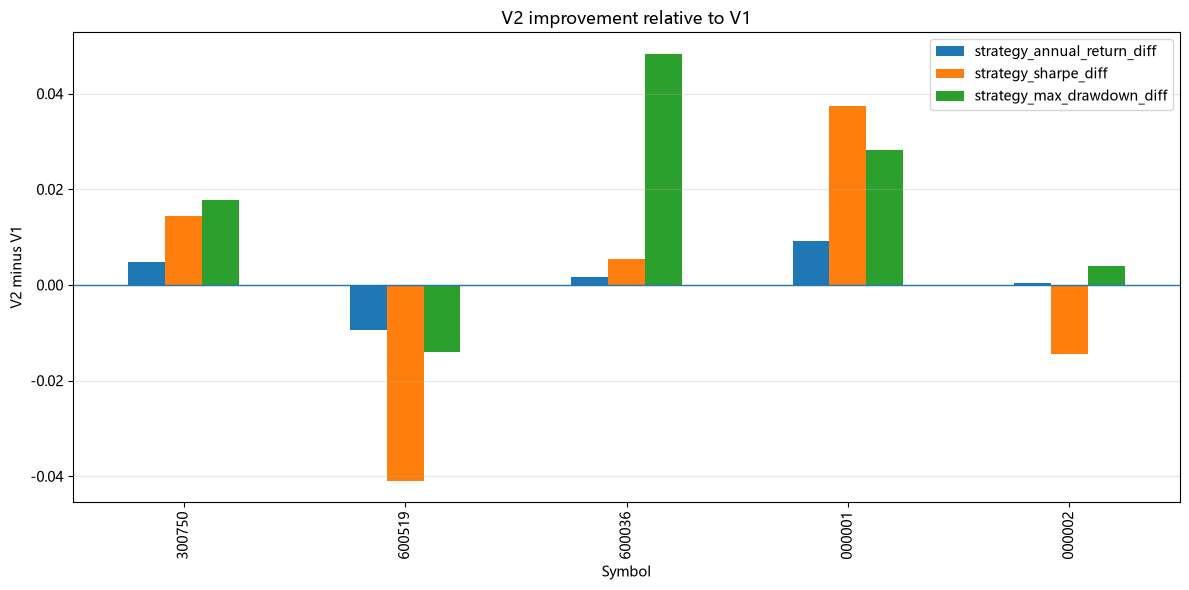

In [29]:
plot_data = (
    v1_vs_v2.set_index("symbol")
    [
        [
            "strategy_annual_return_diff",
            "strategy_sharpe_diff",
            "strategy_max_drawdown_diff",
        ]
    ]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel("Symbol")
ax.set_ylabel("V2 minus V1")

ax.set_title(
    "V2 improvement relative to V1"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [31]:
binary_v1_summary_row = (
    pair_summary.loc[
        (
            pair_summary[
                "baseline_name"
            ] == "binary"
        )
        & (
            pair_summary[
                "candidate_name"
            ] == "v1"
        )
    ].iloc[0]
)

binary_v2_summary_row = (
    pair_summary.loc[
        (
            pair_summary[
                "baseline_name"
            ] == "binary"
        )
        & (
            pair_summary[
                "candidate_name"
            ] == "v2"
        )
    ].iloc[0]
)

v1_v2_summary_row = (
    pair_summary.loc[
        (
            pair_summary[
                "baseline_name"
            ] == "v1"
        )
        & (
            pair_summary[
                "candidate_name"
            ] == "v2"
        )
    ].iloc[0]
)

v1_partial_rate = (
    graded_v1_period_summary[
        "partial_position_rate"
    ].mean()
)

v2_partial_rate = (
    graded_v2_period_summary[
        "partial_position_rate"
    ].mean()
)

v2_downside_retention = (
    v2_attribution[
        "avoided_downside_benefit"
    ]
    / binary_attribution[
        "avoided_downside_benefit"
    ]
)

v2_stock_incremental_row = (
    stock_incremental_win_rate.loc[
        stock_incremental_win_rate[
            "version"
        ] == "v2"
    ].iloc[0]
)

research_checks_v2 = {
    "v2部分仓位比例低于v1": (
        v2_partial_rate
        < v1_partial_rate
    ),

    "v2仍减少二元策略错过上涨": (
        v2_attribution[
            "missed_upside_loss"
        ]
        < binary_attribution[
            "missed_upside_loss"
        ]
    ),

    "v2规避下跌收益保留率至少95%": (
        v2_downside_retention
        >= 0.95
    ),

    "v2的benefit_cost_ratio高于v1": (
        v2_attribution[
            "benefit_cost_ratio"
        ]
        > v1_attribution[
            "benefit_cost_ratio"
        ]
    ),

    "v2主动对数收益高于v1": (
        v2_attribution[
            "active_log_return_sum"
        ]
        > v1_attribution[
            "active_log_return_sum"
        ]
    ),

    "v2相对二元策略夏普胜率至少60%": (
        binary_v2_summary_row[
            "sharpe_win_rate"
        ]
        >= 0.60
    ),

    "v2平均回撤恶化不超过0.3个百分点": (
        binary_v2_summary_row[
            "avg_drawdown_diff"
        ]
        >= -0.003
    ),

    "v2换手增量低于v1": (
        binary_v2_summary_row[
            "avg_turnover_diff"
        ]
        < binary_v1_summary_row[
            "avg_turnover_diff"
        ]
    ),

    "v2成本增量低于v1": (
        binary_v2_summary_row[
            "avg_transaction_cost_diff"
        ]
        < binary_v1_summary_row[
            "avg_transaction_cost_diff"
        ]
    ),

    "v2增量收益股票胜率至少60%": (
        v2_stock_incremental_row[
            "incremental_stock_win_rate"
        ]
        >= 0.60
    ),
}

research_check_table_v2 = pd.DataFrame(
    {
        "check": (
            research_checks_v2.keys()
        ),
        "passed": (
            research_checks_v2.values()
        ),
    }
)

display(research_check_table_v2)

,check,passed
0,v2部分仓位比例低于v1,True
1,v2仍减少二元策略错过上涨,True
2,v2规避下跌收益保留率至少95%,True
3,v2的benefit_cost_ratio高于v1,True
4,v2主动对数收益高于v1,True
5,v2相对二元策略夏普胜率至少60%,True
6,v2平均回撤恶化不超过0.3个百分点,True
7,v2换手增量低于v1,True
8,v2成本增量低于v1,True
9,v2增量收益股票胜率至少60%,True


In [32]:
final_research_summary = pd.DataFrame(
    {
        "metric": [
            "v1部分仓位比例",
            "v2部分仓位比例",
            "v2年化收益相对二元改善",
            "v2夏普相对二元改善",
            "v2夏普改善胜率",
            "v2回撤相对二元变化",
            "v2错过上涨损失",
            "v2规避下跌收益",
            "v2规避下跌保留率",
            "v2 benefit_cost_ratio",
            "v2主动对数收益",
            "v2增量股票胜率",
            "v2相对v1换手变化",
            "v2相对v1成本变化",
        ],
        "value": [
            v1_partial_rate,
            v2_partial_rate,
            binary_v2_summary_row[
                "avg_annual_return_diff"
            ],
            binary_v2_summary_row[
                "avg_sharpe_diff"
            ],
            binary_v2_summary_row[
                "sharpe_win_rate"
            ],
            binary_v2_summary_row[
                "avg_drawdown_diff"
            ],
            v2_attribution[
                "missed_upside_loss"
            ],
            v2_attribution[
                "avoided_downside_benefit"
            ],
            v2_downside_retention,
            v2_attribution[
                "benefit_cost_ratio"
            ],
            v2_attribution[
                "active_log_return_sum"
            ],
            v2_stock_incremental_row[
                "incremental_stock_win_rate"
            ],
            v1_v2_summary_row[
                "avg_turnover_diff"
            ],
            v1_v2_summary_row[
                "avg_transaction_cost_diff"
            ],
        ],
    }
)

display(final_research_summary)

,metric,value
0,v1部分仓位比例,0.1831
1,v2部分仓位比例,0.0171
2,v2年化收益相对二元改善,0.0020
3,v2夏普相对二元改善,0.0138
4,v2夏普改善胜率,0.6000
5,v2回撤相对二元变化,0.0111
6,v2错过上涨损失,33.5897
7,v2规避下跌收益,30.9689
8,v2规避下跌保留率,0.9917
9,v2 benefit_cost_ratio,0.9180


In [33]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

performance_detail.to_csv(
    REPORT_DIR
    / "strategy_performance_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

performance_summary.to_csv(
    REPORT_DIR
    / "strategy_performance_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

pair_summary.to_csv(
    REPORT_DIR
    / "pair_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

binary_vs_v1.to_csv(
    REPORT_DIR
    / "binary_vs_v1.csv",
    index=False,
    encoding="utf-8-sig",
)

binary_vs_v2.to_csv(
    REPORT_DIR
    / "binary_vs_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

v1_vs_v2.to_csv(
    REPORT_DIR
    / "v1_vs_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

attribution_summary.to_csv(
    REPORT_DIR
    / "attribution_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

position_state_summary.to_csv(
    REPORT_DIR
    / "position_state_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

filter_funnel_detail.to_csv(
    REPORT_DIR
    / "v2_filter_funnel_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

filter_funnel_summary.to_csv(
    REPORT_DIR
    / "v2_filter_funnel_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

incremental_state_summary.to_csv(
    REPORT_DIR
    / "incremental_state_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

stock_incremental_summary.to_csv(
    REPORT_DIR
    / "stock_incremental_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

annual_detail.to_csv(
    REPORT_DIR
    / "annual_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

annual_summary.to_csv(
    REPORT_DIR
    / "annual_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

research_check_table_v2.to_csv(
    REPORT_DIR
    / "research_check_table_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

final_research_summary.to_csv(
    REPORT_DIR
    / "final_research_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("分析结果保存完成：", REPORT_DIR)

分析结果保存完成： e:\quant-learning\reports\ma_graded_position_v2


## 分级仓位第二版研究结论

### 1. 条件收紧效果

- v1 部分仓位比例：0.1835	
- v2 部分仓位比例：0.0171	
- v2 部分仓位信号减少比例：90.68%
- 过滤信号最多的条件：5_strong_rebound，共触发143次
- v2 平均在退出后第几天触发：

### 2. 总体绩效

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>baseline_name</th>
      <th>candidate_name</th>
      <th>stock_count</th>
      <th>avg_annual_return_diff</th>
      <th>median_annual_return_diff</th>
      <th>annual_return_win_rate</th>
      <th>avg_sharpe_diff</th>
      <th>median_sharpe_diff</th>
      <th>sharpe_win_rate</th>
      <th>avg_drawdown_diff</th>
      <th>drawdown_win_rate</th>
      <th>avg_calmar_diff</th>
      <th>calmar_win_rate</th>
      <th>avg_excess_return_diff</th>
      <th>excess_return_win_rate</th>
      <th>avg_exposure_diff</th>
      <th>avg_trade_count_diff</th>
      <th>avg_turnover_diff</th>
      <th>avg_transaction_cost_diff</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>binary</td>
      <td>v1</td>
      <td>5</td>
      <td>0.0006</td>
      <td>0.0015</td>
      <td>0.6000</td>
      <td>0.0135</td>
      <td>0.0162</td>
      <td>0.8000</td>
      <td>-0.0057</td>
      <td>0.2000</td>
      <td>-0.0115</td>
      <td>0.8000</td>
      <td>0.0006</td>
      <td>0.6000</td>
      <td>0.0549</td>
      <td>147.8000</td>
      <td>37.5000</td>
      <td>0.0187</td>
    </tr>
    <tr>
      <th>1</th>
      <td>binary</td>
      <td>v2</td>
      <td>5</td>
      <td>0.0020</td>
      <td>0.0000</td>
      <td>0.6000</td>
      <td>0.0138</td>
      <td>0.0017</td>
      <td>0.6000</td>
      <td>0.0111</td>
      <td>0.6000</td>
      <td>0.0000</td>
      <td>0.6000</td>
      <td>0.0020</td>
      <td>0.6000</td>
      <td>0.0051</td>
      <td>25.4000</td>
      <td>6.4800</td>
      <td>0.0032</td>
    </tr>
    <tr>
      <th>2</th>
      <td>v1</td>
      <td>v2</td>
      <td>5</td>
      <td>0.0014</td>
      <td>0.0016</td>
      <td>0.8000</td>
      <td>0.0004</td>
      <td>0.0055</td>
      <td>0.6000</td>
      <td>0.0168</td>
      <td>0.8000</td>
      <td>0.0116</td>
      <td>0.4000</td>
      <td>0.0014</td>
      <td>0.8000</td>
      <td>-0.0498</td>
      <td>-122.4000</td>
      <td>-31.0200</td>
      <td>-0.0155</td>
    </tr>
  </tbody>
</table>
</div>

- v2 相对二元策略的年化收益变化：0.0020	
- v2 相对二元策略的夏普变化：0.0138	
- v2 夏普改善胜率：0.6
- v2 最大回撤变化：0.0111	
- v2 是否明显优于 v1：略微优于v1

### 3. 错过上涨与下跌保护

- 二元策略错过上涨损失：33.9557	
- v1 错过上涨损失：30.3885	
- v2 错过上涨损失：33.5897	
- v2 规避下跌收益保留率：0.9917
- v2 benefit_cost_ratio：0.9180
- v2 是否比 v1 获得更好的收益风险交换：是

### 4. 信号质量

- v2 部分仓位期间平均收益：0.0007
- v2 部分仓位上涨日比例：0.4825
- added_exposure_up 的贡献：0.3613	
- added_exposure_down 的损失：-0.2639	
- v2 是否减少无效反弹仓位：是

### 5. 交易成本

- v1 换手增量：37.5000
- v2 换手增量：6.4800	
- v1 成本增量：0.0187
- v2 成本增量：0.0032
- 条件收紧是否有效减少交易：是

### 6. 稳定性

- v2 增量收益股票胜率：0.6
- v2 是否由单只股票贡献：否
- v2 年度结果是否稳定：否，起伏较大，主要由2019和2020两年贡献，但是其他策略的情况也一样
- 是否多数股票得到一致改善：是

### 7. 当前决定

- 是否保留 v2：是，但是v2的条件可能过紧，且无法分析其中每个条件的作用
- 是否保留近期离场条件：
- 是否保留反弹强度条件：
- 是否保留快均线斜率条件：
- 是否需要研究部分仓位保持机制：
- 是否可以进入新样本验证：否

In [34]:
added_exposure_detail_v2 = (
    incremental_detail_v2.loc[
        incremental_detail_v2[
            "position_increment"
        ] > 0
    ].copy()
)

v2_added_exposure_hit_rate = (
    added_exposure_detail_v2[
        "asset_return"
    ].gt(0).mean()
)

v2_added_exposure_avg_return = (
    added_exposure_detail_v2[
        "asset_return"
    ].mean()
)

v2_added_exposure_net_sum = (
    added_exposure_detail_v2[
        "incremental_net_return"
    ].sum()
)

print(
    "新增仓位上涨日比例：",
    v2_added_exposure_hit_rate,
)

print(
    "新增仓位日平均股票收益：",
    v2_added_exposure_avg_return,
)

print(
    "新增仓位累计净贡献：",
    v2_added_exposure_net_sum,
)

新增仓位上涨日比例： 0.4825174825174825
新增仓位日平均股票收益： 0.0025107797475507373
新增仓位累计净贡献： 0.09676245116992663


In [35]:
v2_partial_signal_frames = []

for symbol, result in (
    graded_v2_results.items()
):
    data = result.copy()

    data["date"] = pd.to_datetime(
        data["date"]
    )

    mask = (
        data["partial_rebound_signal"]
    )

    mask &= data["date"].between(
        DEVELOPMENT_START_DATE,
        DEVELOPMENT_END_DATE,
    )

    partial_signals = data.loc[
        mask,
        [
            "date",
            "symbol",
            "days_since_exit",
            "rebound_score",
            "fast_ma_slope",
        ],
    ].copy()

    v2_partial_signal_frames.append(
        partial_signals
    )

v2_partial_signal_detail = pd.concat(
    v2_partial_signal_frames,
    ignore_index=True,
)

print(
    "平均退出后触发天数：",
    v2_partial_signal_detail[
        "days_since_exit"
    ].mean(),
)

print(
    "中位数退出后触发天数：",
    v2_partial_signal_detail[
        "days_since_exit"
    ].median(),
)

display(
    v2_partial_signal_detail[
        "days_since_exit"
    ].describe()
)

平均退出后触发天数： 11.132867132867133
中位数退出后触发天数： 11.0


count   143.0000
mean     11.1329
std       4.6425
min       3.0000
25%       8.0000
50%      11.0000
75%      14.0000
max      20.0000
Name: days_since_exit, dtype: float64

In [36]:
exit_day_distribution = (
    v2_partial_signal_detail[
        "days_since_exit"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "days_since_exit"
    )
    .reset_index(
        name="signal_count"
    )
)

display(exit_day_distribution)

,days_since_exit,signal_count
0,3.0000,3
1,4.0000,4
2,5.0000,8
3,6.0000,15
4,7.0000,5
5,8.0000,12
6,9.0000,13
7,10.0000,6
8,11.0000,12
9,12.0000,14


## 分级仓位第二版当前决定

* 是否保留 v2：暂时保留为当前候选规则。v2 在年化收益、夏普、最大回撤、换手和交易成本方面均优于第一版，但收益增量和跨股票稳定性仍然有限，尚不能冻结为最终策略。

* 是否保留近期离场条件：暂时保留。该条件符合“只处理离场后快速反弹”的研究目标，并可能是部分仓位比例从 18.35% 降低至 1.71% 的重要原因，但其独立贡献尚未经过验证。

* 是否保留反弹强度条件：暂时保留。v2 明显减少了无效反弹仓位并保留了 99.17% 的下跌保护，反弹强度条件可能发挥了重要作用，但它可能与价格站上快均线及快均线斜率转正存在信息重叠。

* 是否保留快均线斜率条件：暂时保留，但优先检查是否可以删除。快均线斜率与价格站上快均线、五日强反弹均描述短期价格增强，可能属于重复过滤条件。

* 是否需要研究部分仓位保持机制：暂时不需要。当前首要问题是识别三个过滤条件各自的边际贡献。在信号规则尚未简化和冻结之前加入仓位保持机制，会使策略结构进一步复杂化。

* 是否可以进入新样本验证：暂时不可以。下一阶段应先完成条件消融实验，确定近期离场、反弹强度和快均线斜率是否分别具有独立价值。规则简化并冻结后，再进入新的股票或时间样本验证。
